<a href="https://colab.research.google.com/github/smita-github1/-Health-insurance-Prediction-Model/blob/main/Copy_of_extraAQ5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Block 1: Setup and Data Loading
This first block imports the necessary libraries and loads your dataset into a pandas DataFrame.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset from the uploaded file
# Ensure 'Stature_mass - Sheet1.csv' is uploaded to your Colab session.
file_name = 'Stature_mass - Sheet1.csv'
df = pd.read_csv(file_name)

# Define the column you want to analyze
# Change this to 'Mass_kg' if you want to analyze mass instead.
column_to_analyze = 'Stature_cm'
population_data = df[column_to_analyze].dropna()

print(f"Dataset '{file_name}' loaded successfully.")
print(f"Analysis will be performed on the '{column_to_analyze}' column.")


Dataset 'Stature_mass - Sheet1.csv' loaded successfully.
Analysis will be performed on the 'Stature_cm' column.


Block 2: Population Analysis and Histogram
This block calculates the mean and standard deviation of the entire population and plots its distribution.

--- Population Statistics for 'Stature_cm' ---
Population Mean (μ): 168.69
Population Standard Deviation (σ): 9.20



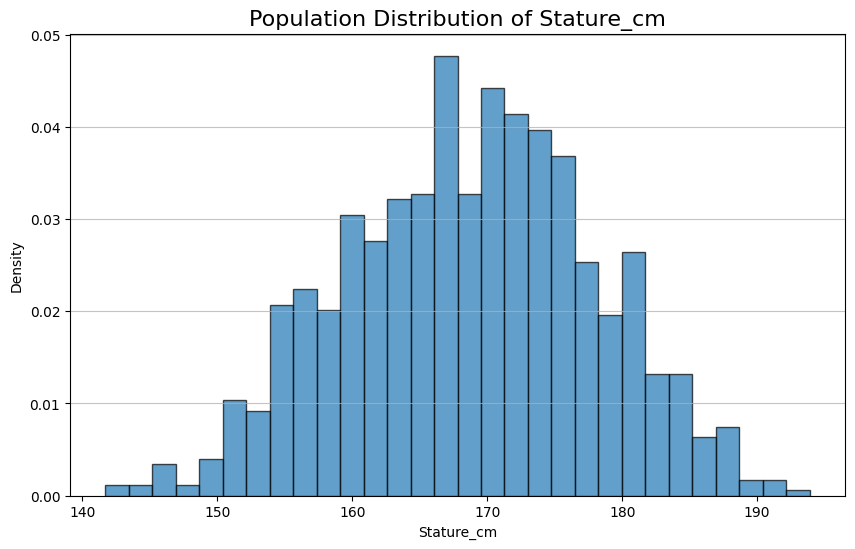

In [ ]:
# Calculate population statistics
population_mean = population_data.mean()
population_std = population_data.std()

print(f"--- Population Statistics for '{column_to_analyze}' ---")
print(f"Population Mean (μ): {population_mean:.2f}")
print(f"Population Standard Deviation (σ): {population_std:.2f}\n")

# Plot the histogram of the population data
plt.figure(figsize=(10, 6))
plt.hist(population_data, bins=30, density=True, edgecolor='k', alpha=0.7)
plt.title(f'Population Distribution of {column_to_analyze}', fontsize=16)
plt.xlabel(f'{column_to_analyze}')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
plt.show()


Block 3: Bootstrap Simulation for Sample Means
This block performs the bootstrap resampling to generate the sampling distribution of the mean. It then plots the distributions for different sample sizes and prints the summary table.



--- Analysis of Sample Means ---


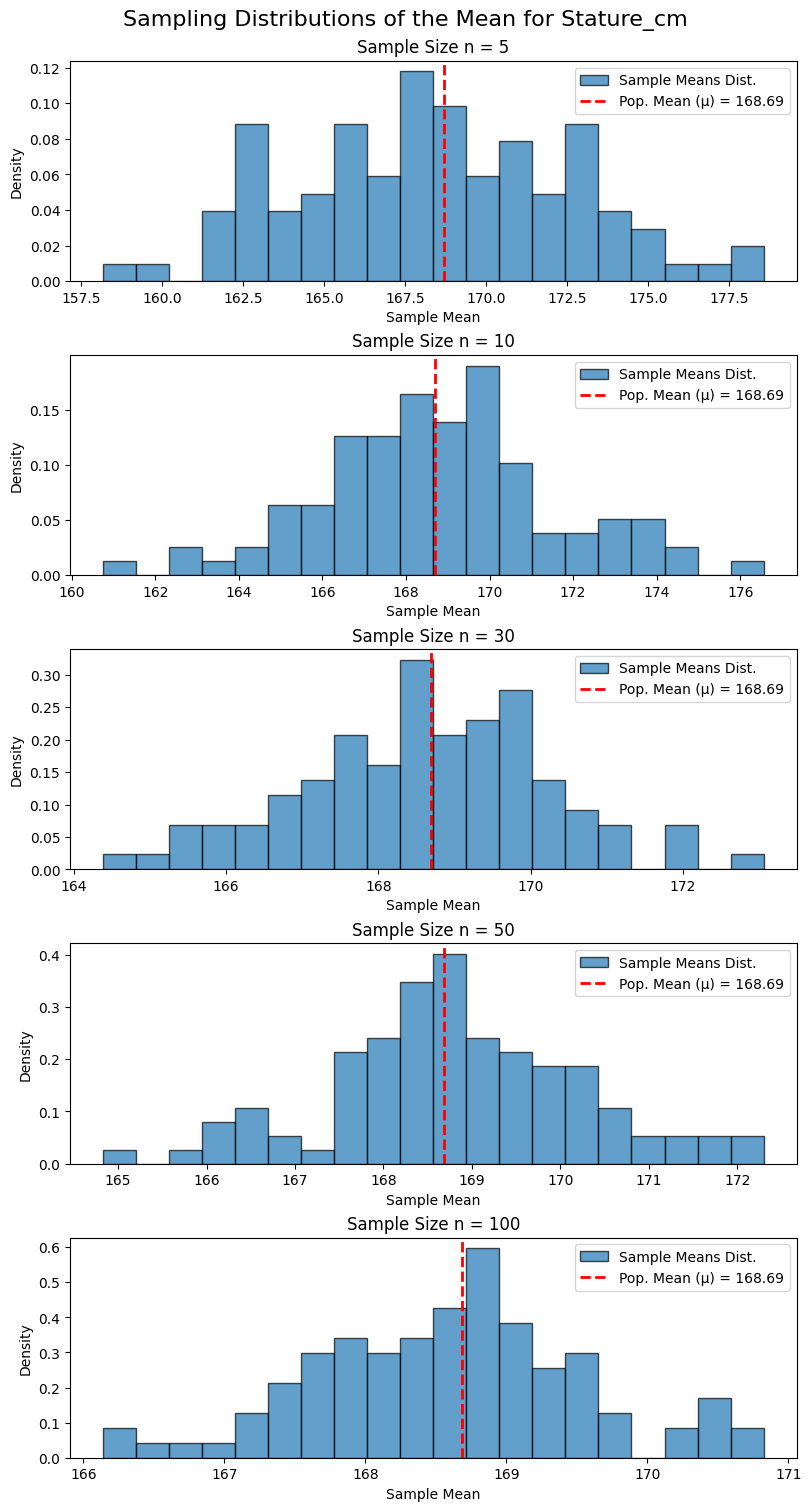

Summary Table for Sample Means:
 Sample Size (n)  Mean of Sample Means  Std Dev of Sample Means  Theoretical Std Error (σ/√n)
             5.0            168.358400                 4.277905                      4.115618
            10.0            168.820000                 2.838432                      2.910182
            30.0            168.597633                 1.632246                      1.680194
            50.0            168.823580                 1.402435                      1.301473
           100.0            168.590920                 0.953202                      0.920280


In [ ]:
# --- Bootstrap Simulation for Sample Means ---
print("\n--- Analysis of Sample Means ---")
sample_sizes = [5, 10, 30, 50, 100]
num_samples = 100 # Number of bootstrap samples to draw for each size n

# Prepare a DataFrame to store results
results_mean_df = pd.DataFrame(columns=[
    'Sample Size (n)', 'Mean of Sample Means', 'Std Dev of Sample Means', 'Theoretical Std Error (σ/√n)'
])

# Create subplots for the histograms
fig, axes = plt.subplots(nrows=len(sample_sizes), ncols=1, figsize=(8, 15), constrained_layout=True)
fig.suptitle(f'Sampling Distributions of the Mean for {column_to_analyze}', fontsize=16)

for i, n in enumerate(sample_sizes):
    # Perform bootstrap resampling
    sample_means = [population_data.sample(n, replace=True).mean() for _ in range(num_samples)]

    # Calculate and store statistics
    mean_of_means = np.mean(sample_means)
    std_of_means = np.std(sample_means, ddof=1)
    theoretical_std_error = population_std / np.sqrt(n)
    results_mean_df.loc[i] = [n, mean_of_means, std_of_means, theoretical_std_error]

    # Plot histogram for the current sample size n
    ax = axes[i]
    ax.hist(sample_means, bins=20, density=True, edgecolor='k', alpha=0.7, label='Sample Means Dist.')
    ax.axvline(population_mean, color='r', linestyle='--', linewidth=2, label=f'Pop. Mean (μ) = {population_mean:.2f}')
    ax.set_title(f'Sample Size n = {n}')
    ax.set_xlabel('Sample Mean')
    ax.set_ylabel('Density')
    ax.legend()

plt.show()

# Print the summary table
print("Summary Table for Sample Means:")
print(results_mean_df.to_string(index=False))


Block 4: Bootstrap Simulation for Sample Sums
This final block performs the bootstrap resampling to generate the sampling distribution of the sum. It plots the corresponding distributions and prints the final summary table.


--- Analysis of Sample Sums ---


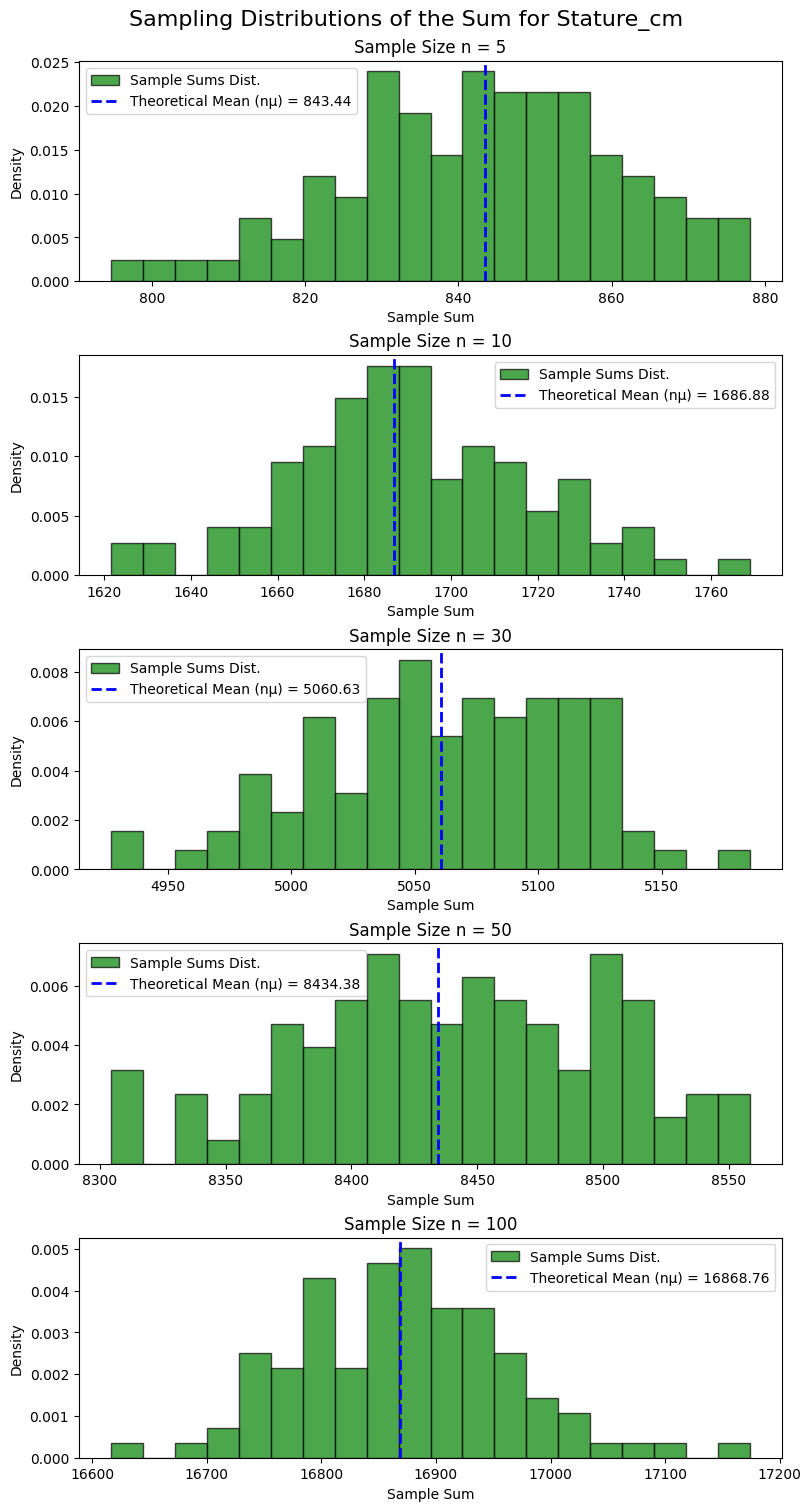

Summary Table for Sample Sums:
 Sample Size (n)  Mean of Sample Sums  Theoretical Mean (n*μ)  Std Dev of Sample Sums  Theoretical Std Dev (σ*√n)
             5.0              843.110                 843.438               17.610738                   20.578092
            10.0             1690.975                1686.876               28.162947                   29.101817
            30.0             5063.078                5060.628               51.341008                   50.405826
            50.0             8441.266                8434.380               60.972268                   65.073642
           100.0            16870.565               16868.760               95.155092                   92.028027


In [ ]:
# --- Bootstrap Simulation for Sample Sums ---
print("\n--- Analysis of Sample Sums ---")
sample_sizes = [5, 10, 30, 50, 100]
num_samples = 100 # Number of bootstrap samples to draw for each size n

# Prepare a DataFrame to store results
results_sum_df = pd.DataFrame(columns=[
    'Sample Size (n)', 'Mean of Sample Sums', 'Theoretical Mean (n*μ)', 'Std Dev of Sample Sums', 'Theoretical Std Dev (σ*√n)'
])

# Create subplots for the histograms
fig, axes = plt.subplots(nrows=len(sample_sizes), ncols=1, figsize=(8, 15), constrained_layout=True)
fig.suptitle(f'Sampling Distributions of the Sum for {column_to_analyze}', fontsize=16)

for i, n in enumerate(sample_sizes):
    # Perform bootstrap resampling
    sample_sums = [population_data.sample(n, replace=True).sum() for _ in range(num_samples)]

    # Calculate and store statistics
    mean_of_sums = np.mean(sample_sums)
    theoretical_mean = n * population_mean
    std_of_sums = np.std(sample_sums, ddof=1)
    theoretical_std = population_std * np.sqrt(n)
    results_sum_df.loc[i] = [n, mean_of_sums, theoretical_mean, std_of_sums, theoretical_std]

    # Plot histogram for the current sample size n
    ax = axes[i]
    ax.hist(sample_sums, bins=20, density=True, edgecolor='k', alpha=0.7, color='g', label='Sample Sums Dist.')
    ax.axvline(theoretical_mean, color='b', linestyle='--', linewidth=2, label=f'Theoretical Mean (nμ) = {theoretical_mean:.2f}')
    ax.set_title(f'Sample Size n = {n}')
    ax.set_xlabel('Sample Sum')
    ax.set_ylabel('Density')
    ax.legend()

plt.show()

# Print the summary table
print("Summary Table for Sample Sums:")
print(results_sum_df.to_string(index=False))
